### TRBs 

Tick run bars

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Imports completados")

✓ Imports completados


In [ ]:

from pathlib import Path
import sys

cwd = Path().resolve()
for p in [cwd] + list(cwd.parents):
    if (p / "utils").is_dir():
        sys.path.insert(0, str(p))
        break

from utils.download_data_binance import DowloadDataBinance as dt 
from utils.bars.runs_bars import RunBars as rb
from utils.bars.info_bars import InfoBars as ib
from utils.bars.bars_visualizer import BarsVisualizer as bv

In [3]:
data_path = '../data/raw'
run_bars = rb(data_path)
info_bars = ib(data_path)
download_data = dt(data_path)
bars_visualizer = bv()

In [4]:
df = download_data.download_trades_binance(
    symbol='BTCUSDT',
    hours=120,  
    max_trades=300000
)

download_data.show_info(df)

Descargando trades de BTCUSDT...
Trades: 200,000 | Iter: 200
✓ Descargados: 200,000 trades
Guardado en: ../data/rawBTCUSDT_trades_20251030_181413.csv

INFORMACIÓN DE LOS DATOS
Total trades: 112,787
Período: 2025-10-25 23:12:26.553000 a 2025-10-26 09:53:43.706000
Duración: 10.7 horas

Primeros 5 trades:
                timestamp      price  quantity  dollar_value
0 2025-10-25 23:12:26.553  111594.29   0.00015     16.739143
1 2025-10-25 23:12:29.438  111594.30   0.00016     17.855088
2 2025-10-25 23:12:29.480  111594.29   0.00027     30.130458
3 2025-10-25 23:12:29.577  111594.29   0.00369    411.782930
4 2025-10-25 23:12:31.867  111594.29   0.01027   1146.073358

Estadísticas:
                           timestamp          price       quantity  \
count                         112787  112787.000000  112787.000000   
mean   2025-10-26 05:21:21.861326592  111749.712602       0.016424   
min       2025-10-25 23:12:26.553000  111260.450000       0.000010   
25%    2025-10-26 02:10:32.20049996

In [90]:
trb_bars = run_bars.get_trbs(df)
drb_bars = run_bars.get_drbs(df)
vrb_bars = run_bars.get_vrbs(df)

In [91]:
tib_bars = info_bars.get_tibs(df, init_exp_T=1100)
dib_bars = info_bars.get_dibs(df, init_exp_T=1500)
vib_bars = info_bars.get_vibs(df, init_exp_T=1500)

In [92]:
print("len run bars: ", len(trb_bars), len(drb_bars), len(vrb_bars))
print("len info bars: ", len(tib_bars), len(dib_bars), len(vib_bars))

len run bars:  86 51 51
len info bars:  117 42 42


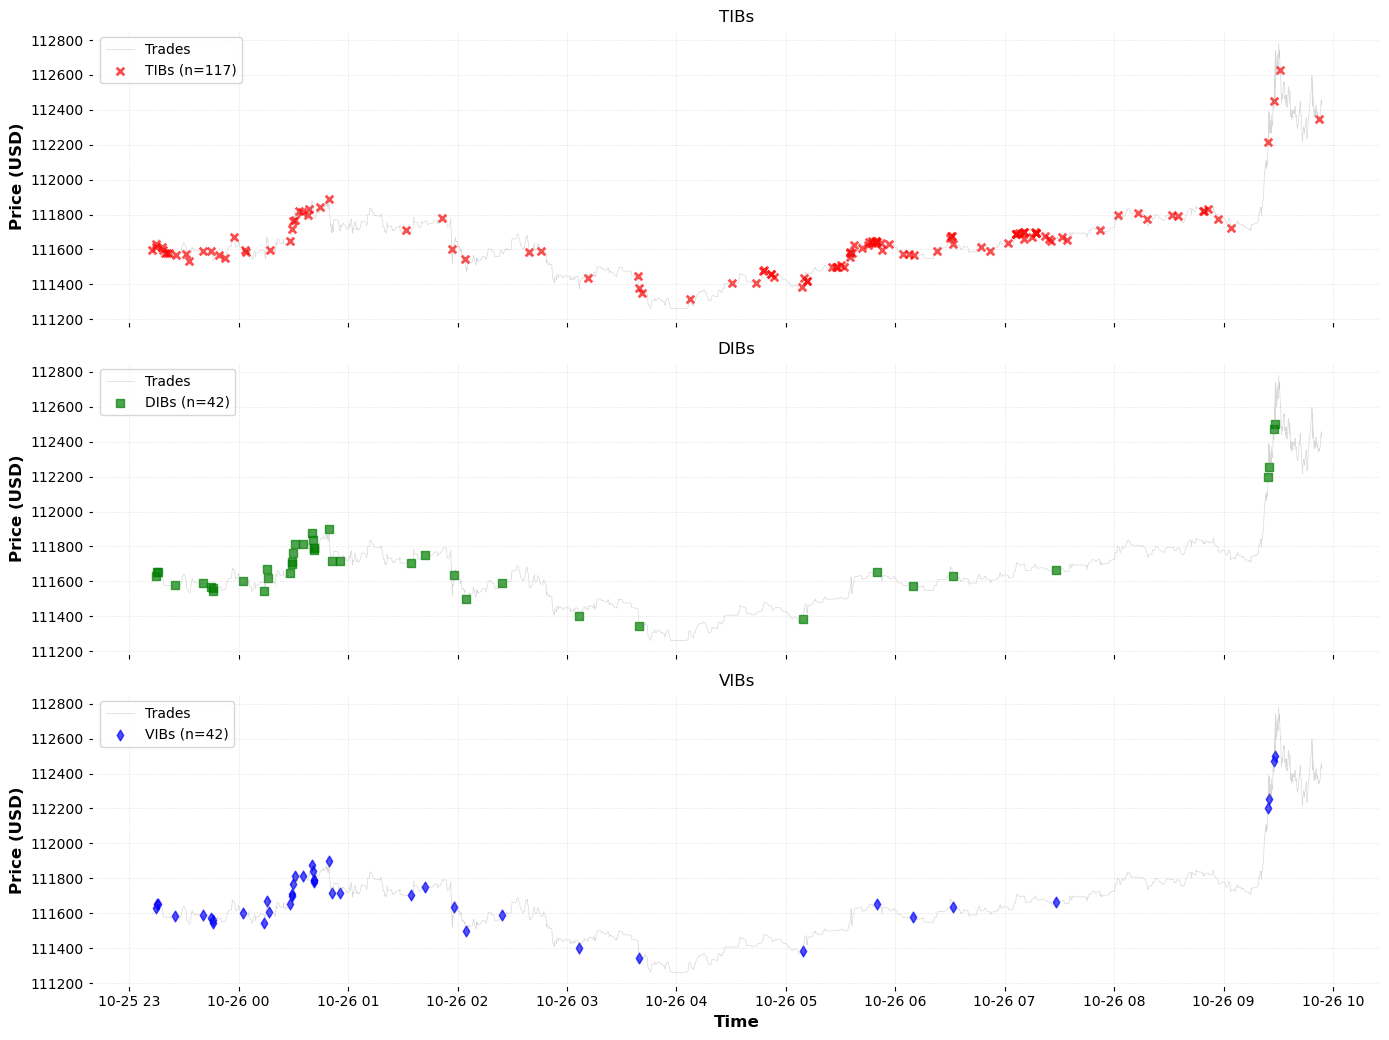

In [93]:
bars_visualizer.plot_comparison(df, {
    'TIBs': (tib_bars, 'red', 'x'),
    'DIBs': (dib_bars, 'green', 's'),
    'VIBs': (vib_bars, 'blue', 'd'),
    
})


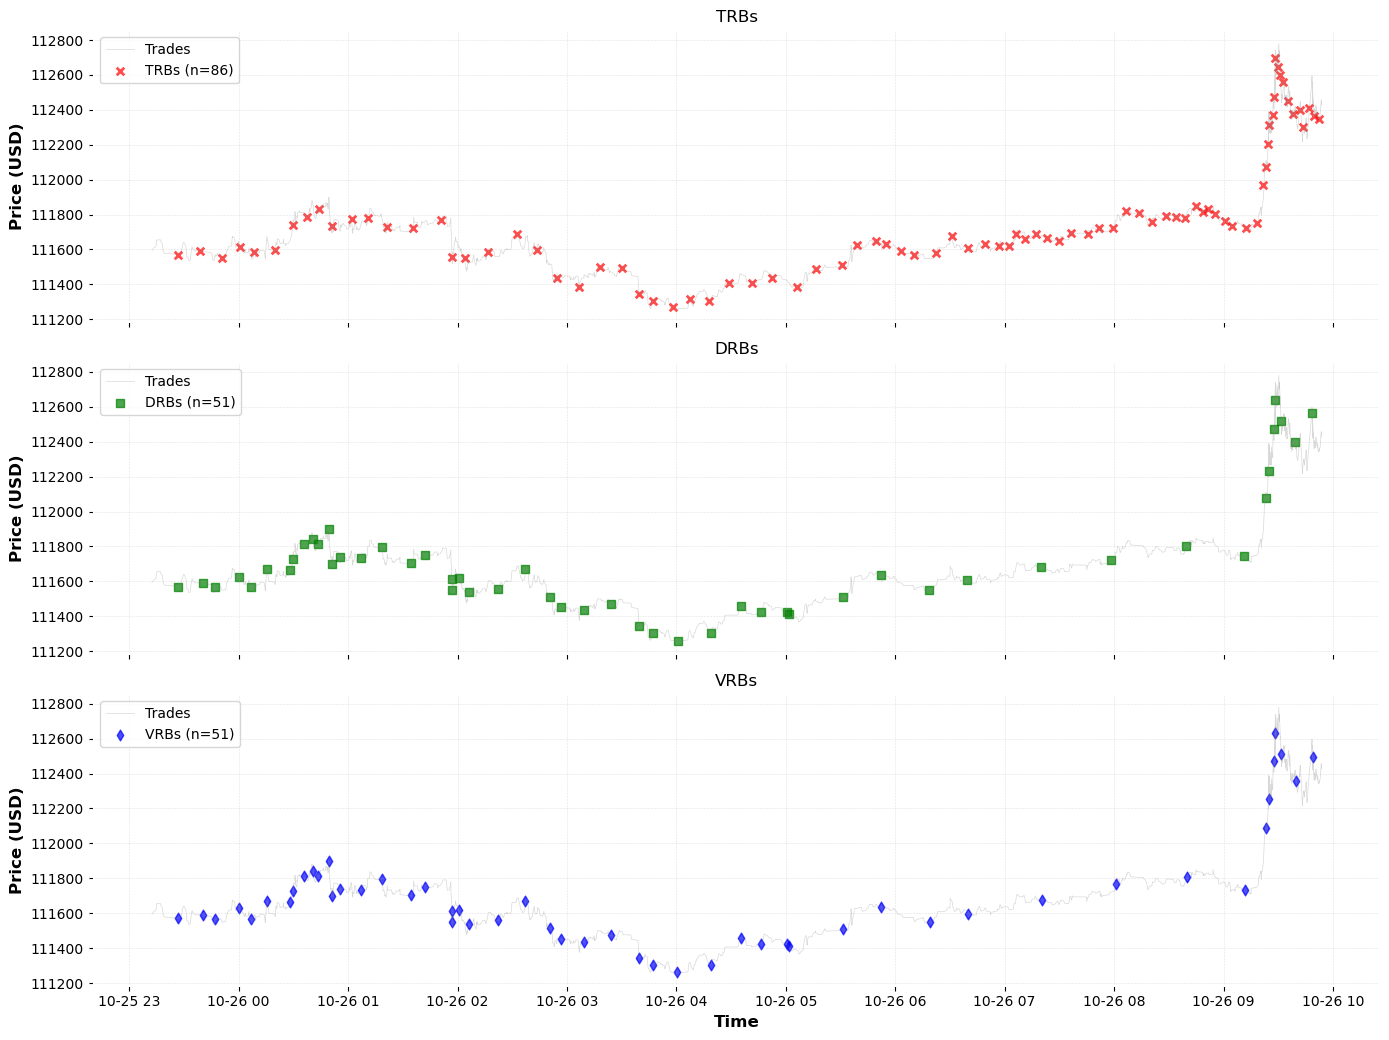

In [95]:
bars_visualizer.plot_comparison(df, {
    'TRBs': (trb_bars, 'red', 'x'),
    'DRBs': (drb_bars, 'green', 's'),
    'VRBs': (vrb_bars, 'blue', 'd'),
    
})

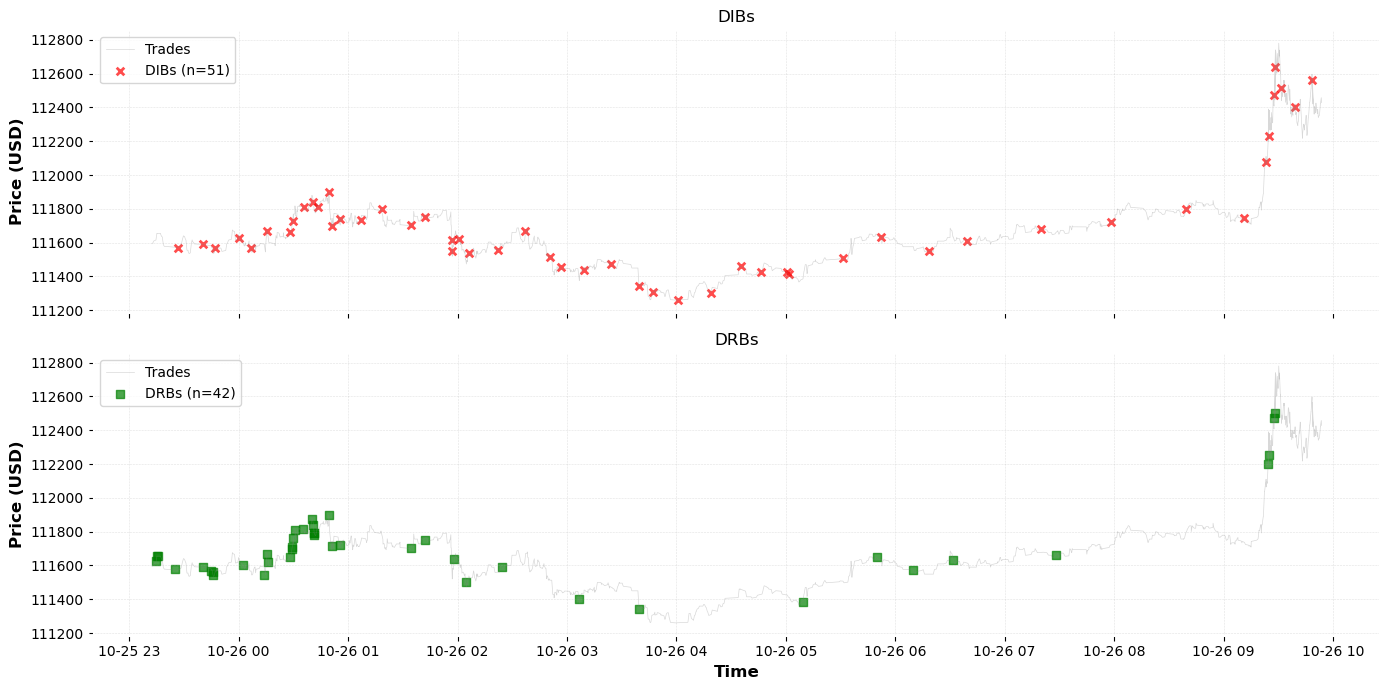

In [ ]:
bars_visualizer.plot_comparison(df, {
    'DIBs': (drb_bars, 'red', 'x'),
    'DRBs': (dib_bars, 'green', 'x'),
})

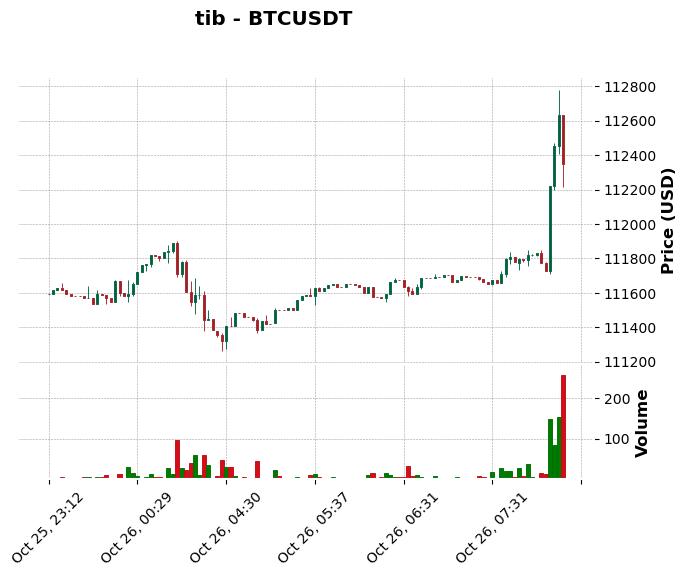

In [69]:
bars_visualizer.candle_chart(tib_bars, bar_type='tib')

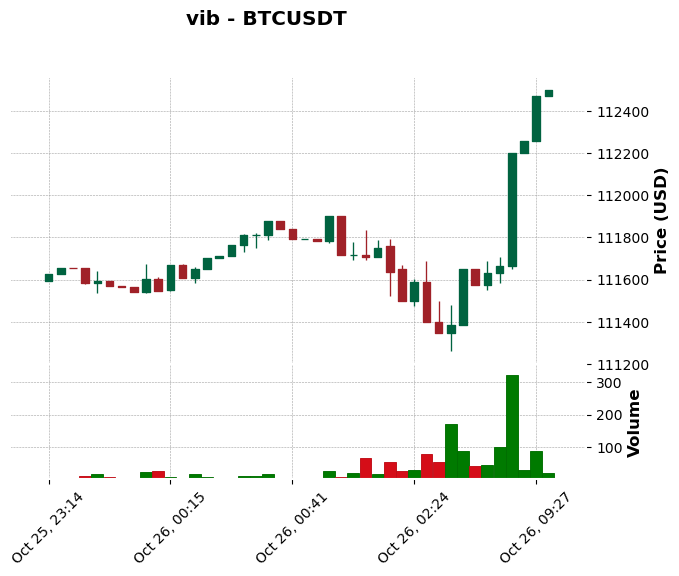

In [96]:
bars_visualizer.candle_chart(vib_bars, bar_type='vib')

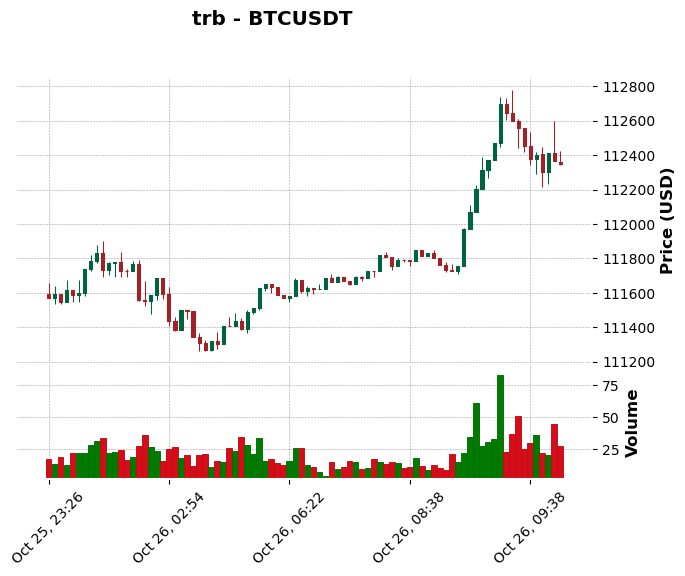

In [70]:
bars_visualizer.candle_chart(trb_bars, bar_type='trb')

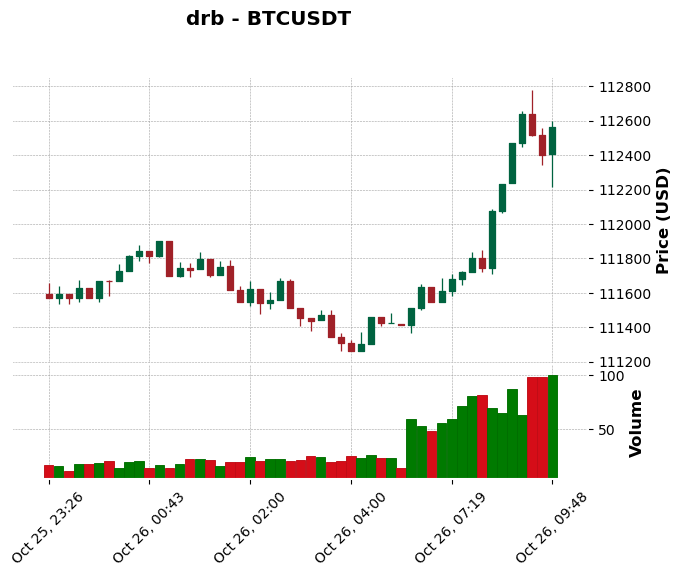

In [97]:
bars_visualizer.candle_chart(drb_bars, bar_type='drb')

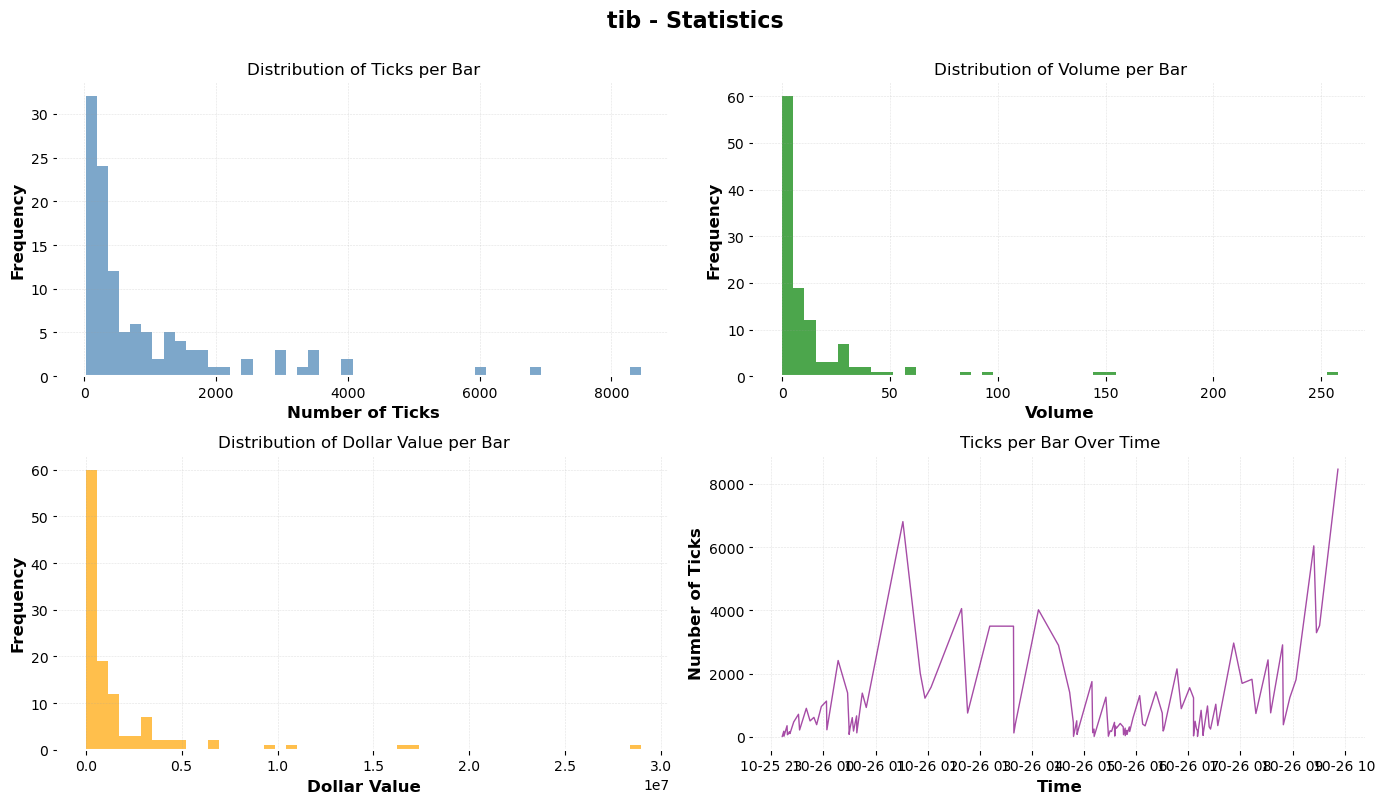

In [73]:
bars_visualizer.plot_bar_statistics(tib_bars, bar_type='tib')

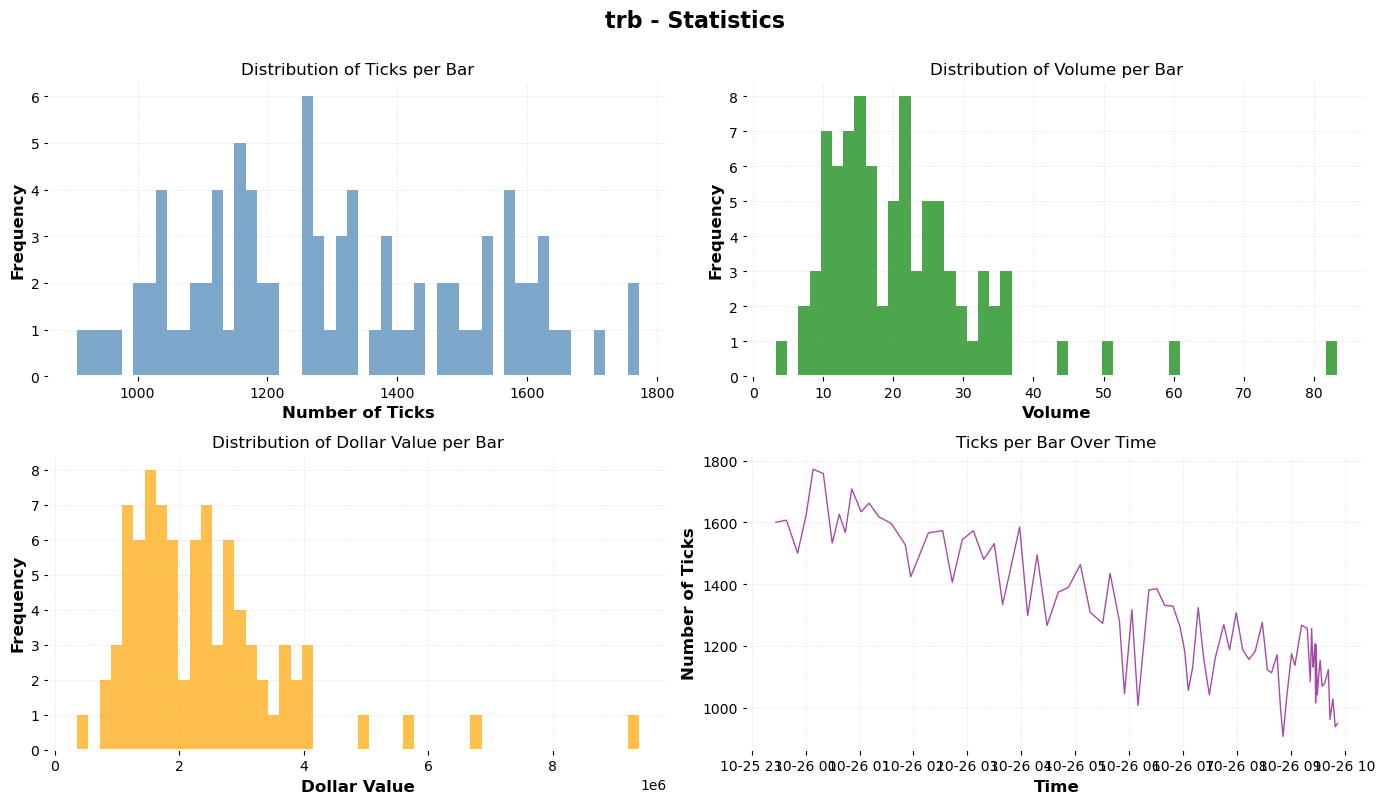

In [74]:
bars_visualizer.plot_bar_statistics(trb_bars, bar_type='trb')

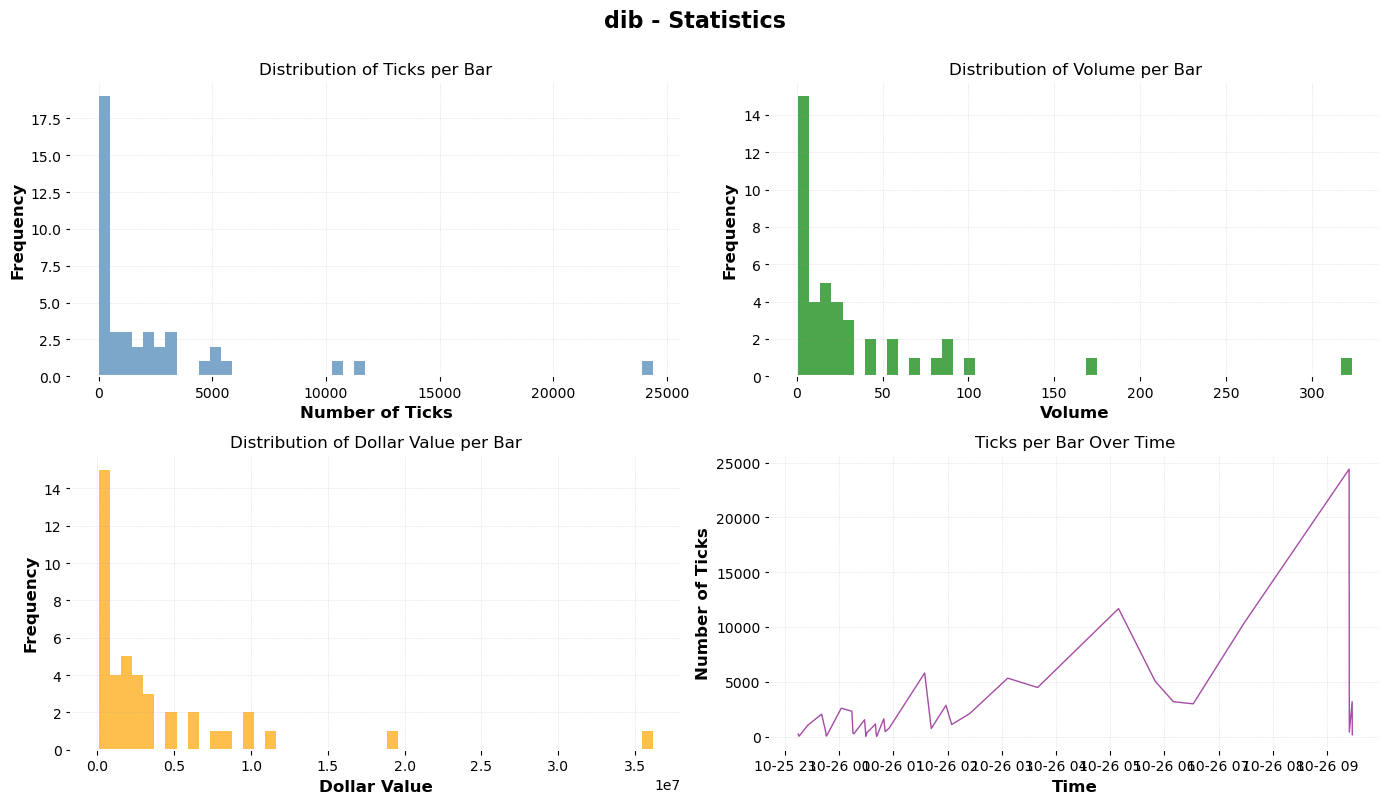

In [ ]:
bars_visualizer.plot_bar_statistics(dib_bars, bar_type='dib')

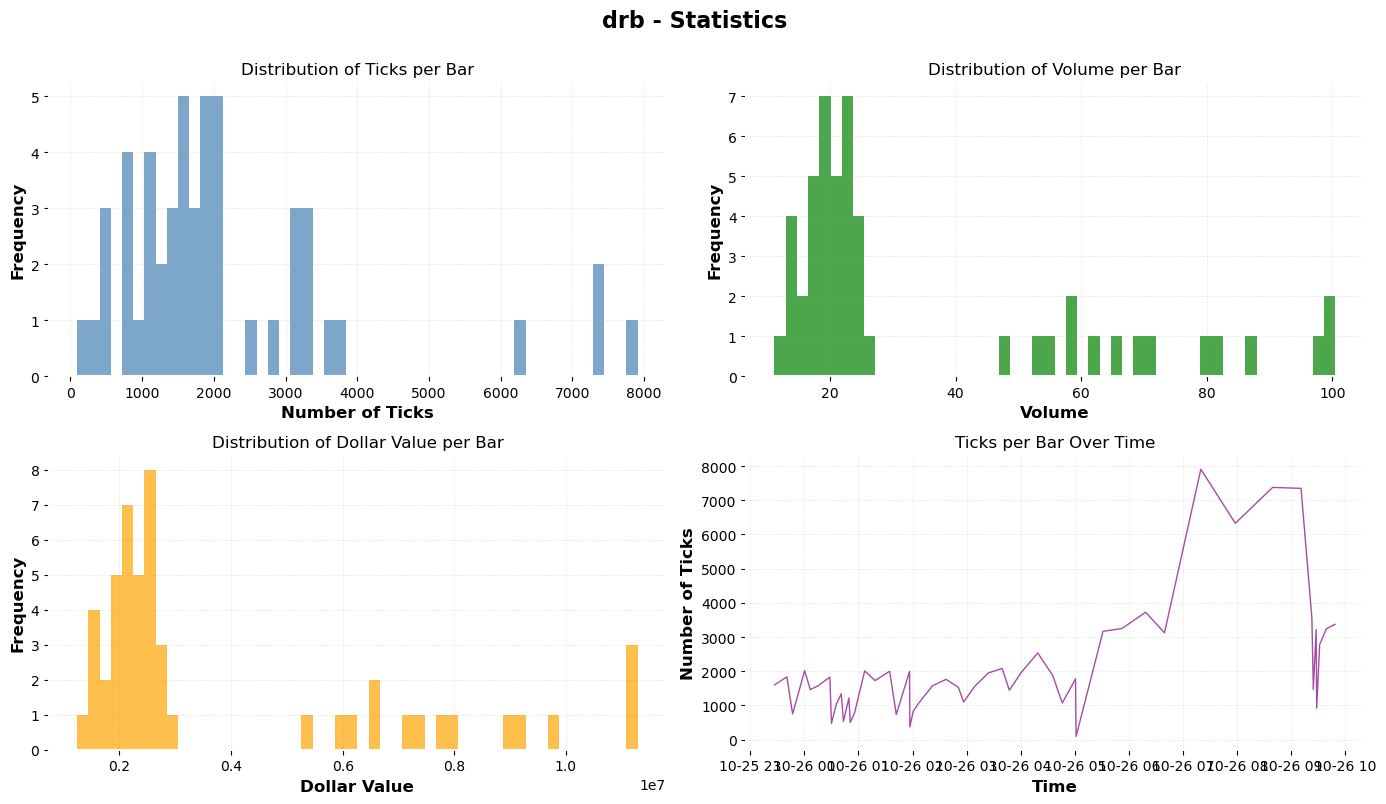

In [98]:
bars_visualizer.plot_bar_statistics(drb_bars, bar_type='drb')